In [1]:
from lightning import Trainer
from fcn import load_data
from gnn import load_data as load_data_gnn
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from fcn_model import FlowModel
from gnn_model import GraphModel
import torch
from fcn import filenames
from scipy.stats import binned_statistic
import pandas as pd

fcn.py is running
Imports took 0:00:10.332863. This program is using: cpu


In [2]:

#TODO: Matrix plot of performance cross simulations but with coverage

In [3]:
import scienceplots
plt.style.use('science')

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [4]:
boxsizes = {
    'TNG': 75.,
    'ASTRID': 250.,
}

In [5]:
checkpoint_path = Path('/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/')
graph_radius = 2000.
gnn_data_path = Path(f"/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/carol_processed_data/gnn_{graph_radius:.1f}/")
trainer = Trainer()  
z = 4

def get_dataloader(sim, training_sim, z, observable_features_only=False):
    _, _, test_loader = load_data(
        datadir = filenames[sim][z],
        trainsim_datadir = filenames[training_sim][z],
        observable_features_only=observable_features_only,
        batch_size=100,
    )
    return test_loader

def load_model(training_sim, z, observable_features_only=False):
    run_name = f'FCN_{training_sim}_z{z}' if not observable_features_only else f'FCN_{training_sim}_z{z}_observable_features_only'
    data_path = checkpoint_path / run_name
    # find .ckpt file in folder
    print(data_path)
    ckpt_file = next(data_path.glob('*.ckpt'))
    model = FlowModel.load_from_checkpoint(ckpt_file)
    return model

def get_predictions(training_sim, testing_sim, z, observable_features_only=False):
    model = load_model(training_sim, z, observable_features_only)
    test_loader = get_dataloader(testing_sim, training_sim, z, observable_features_only)
    predictions = trainer.predict(model, test_loader)
    predictions = torch.concatenate(predictions, dim=1)
    truths = torch.cat([batch[1] for batch in test_loader], dim=0)

    train_stats = pd.read_csv(f'{filenames[training_sim][z]}_stats.csv', index_col=0)
    mass_mean = train_stats.loc['HaloMass', 'mean']
    mass_std = train_stats.loc['HaloMass', 'std']
    predictions = (predictions * mass_std) + mass_mean
    truths = (truths * mass_std) + mass_mean 
    return truths.squeeze(), predictions.squeeze()

    
def get_gnn_dataloader(sim, training_sim, z, observable_features_only=False):
    _, _, test_loader = load_data_gnn(
        datadir = gnn_data_path,
        sim=sim,
        train_sim=training_sim,
        z=z,
        observable_features_only=observable_features_only,
        batch_size=64,
    )
    return test_loader

def load_gnn_model(training_sim, z, observable_features_only=False):
    run_name = f'GNN_{training_sim}_z{z}' if not observable_features_only else f'GNN_{training_sim}_z{z}_observable_features_only'
    data_path = checkpoint_path / run_name
    # find .ckpt file in folder
    print(data_path)
    ckpt_file = next(data_path.glob('*.ckpt'))
    model = GraphModel.load_from_checkpoint(ckpt_file)
    return model

def get_gnn_predictions(training_sim, testing_sim, z, observable_features_only=False):
    model = load_gnn_model(training_sim, z, observable_features_only)
    test_loader = get_gnn_dataloader(testing_sim, training_sim, z, observable_features_only)
    predictions = trainer.predict(model, test_loader)
    predictions = torch.concatenate(predictions, dim=1)
    truths = torch.cat([batch[1] for batch in test_loader], dim=0)

    train_stats = pd.read_csv(f'{filenames[training_sim][z]}_stats.csv', index_col=0)
    mass_mean = train_stats.loc['HaloMass', 'mean']
    mass_std = train_stats.loc['HaloMass', 'std']
    predictions = (predictions * mass_std) + mass_mean
    truths = (truths * mass_std) + mass_mean 
    return truths.squeeze(), predictions.squeeze()

/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [6]:
trained_on = ['TNG', 'ASTRID']
tested_on = ['TNG', 'ASTRID']
truths = {}
predictions = {}

for train in trained_on:
    for  test in tested_on:
        print(train, test)
        truths[f'{train}_{test}'], predictions[f'{train}_{test}'] = get_predictions(
            train, test, z, observable_features_only=False,
        )



TNG TNG
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_TNG_z4


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



TNG ASTRID
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_TNG_z4


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



ASTRID TNG
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_ASTRID_z4


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



ASTRID ASTRID
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_ASTRID_z4


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


In [7]:

truths_observable = {}
predictions_observable = {}

for train in trained_on:
    for  test in tested_on:
        print(train, test)
        truths_observable[f'{train}_{test}'], predictions_observable[f'{train}_{test}'] = get_predictions(
            train, test, z, observable_features_only=True,
        )



TNG TNG
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_TNG_z4_observable_features_only


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



TNG ASTRID
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_TNG_z4_observable_features_only


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



ASTRID TNG
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_ASTRID_z4_observable_features_only


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



ASTRID ASTRID
/n/holystore01/LABS/itc_lab/Lab/galaxyGNN/models/FCN_ASTRID_z4_observable_features_only


/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holystore01/LABS/iaifi_lab/Lab/environments/carol ...
/n/holystore01/LABS/iaifi_lab/Lab/environments/carol/envs/torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


In [8]:


def make_matrix_plots(truths, predictions, trained_on, tested_on, plot_every_n_points=None):
    fig, axes = plt.subplots(len(tested_on), len(trained_on), 
                            figsize=(4*len(trained_on), 4*len(tested_on)),sharex=True, sharey=True)
    
    for j, train in enumerate(trained_on):
        fig.text(0.27 + j*0.45, 0.92, f'Trained on {train}', 
                ha='center', va='center', fontsize=12)

    for i, test in enumerate(tested_on):
        fig.text(0.92, 0.73 - i*0.45, f'Tested on {test}', 
                ha='center', va='center', rotation=-90, fontsize=12)
    
    for i, test in enumerate(tested_on):
        for j, train in enumerate(trained_on):
            if plot_every_n_points is None:
                plot_every = 1
            else:
                plot_every = plot_every_n_points[test]
            ax = axes[i, j]
            

            key = f'{train}_{test}'
            
            mean = predictions[key].mean(axis=0)
            std = predictions[key].std(axis=0)
            
            ax.errorbar(
                truths[key][::plot_every], 
                mean[::plot_every],
                yerr=std[::plot_every],
                color='navy', 
                linestyle='', 
                markersize=0.5, 
                marker='o',
                capsize=5,
            )
            
           
            # diagonal line for truths with min and max ranges
            ax.plot(
                [truths[key][:].min(), truths[key][:].max()],
                [truths[key][:].min(), truths[key][:].max()],
                color='black', linestyle='--'
            )

            ax.grid(True,alpha=0.5)
            
            if i == len(tested_on) - 1:
                ax.set_xlabel('True')
            
            if j == 0:
                ax.set_ylabel('Pred')

            # Add mse to plot
            mse = ((mean[:] - truths[key][:])**2).mean()
            ax.text(0.05, 0.9, f'MSE: {mse:.4e}', transform=ax.transAxes)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9, right=0.9)
    return fig

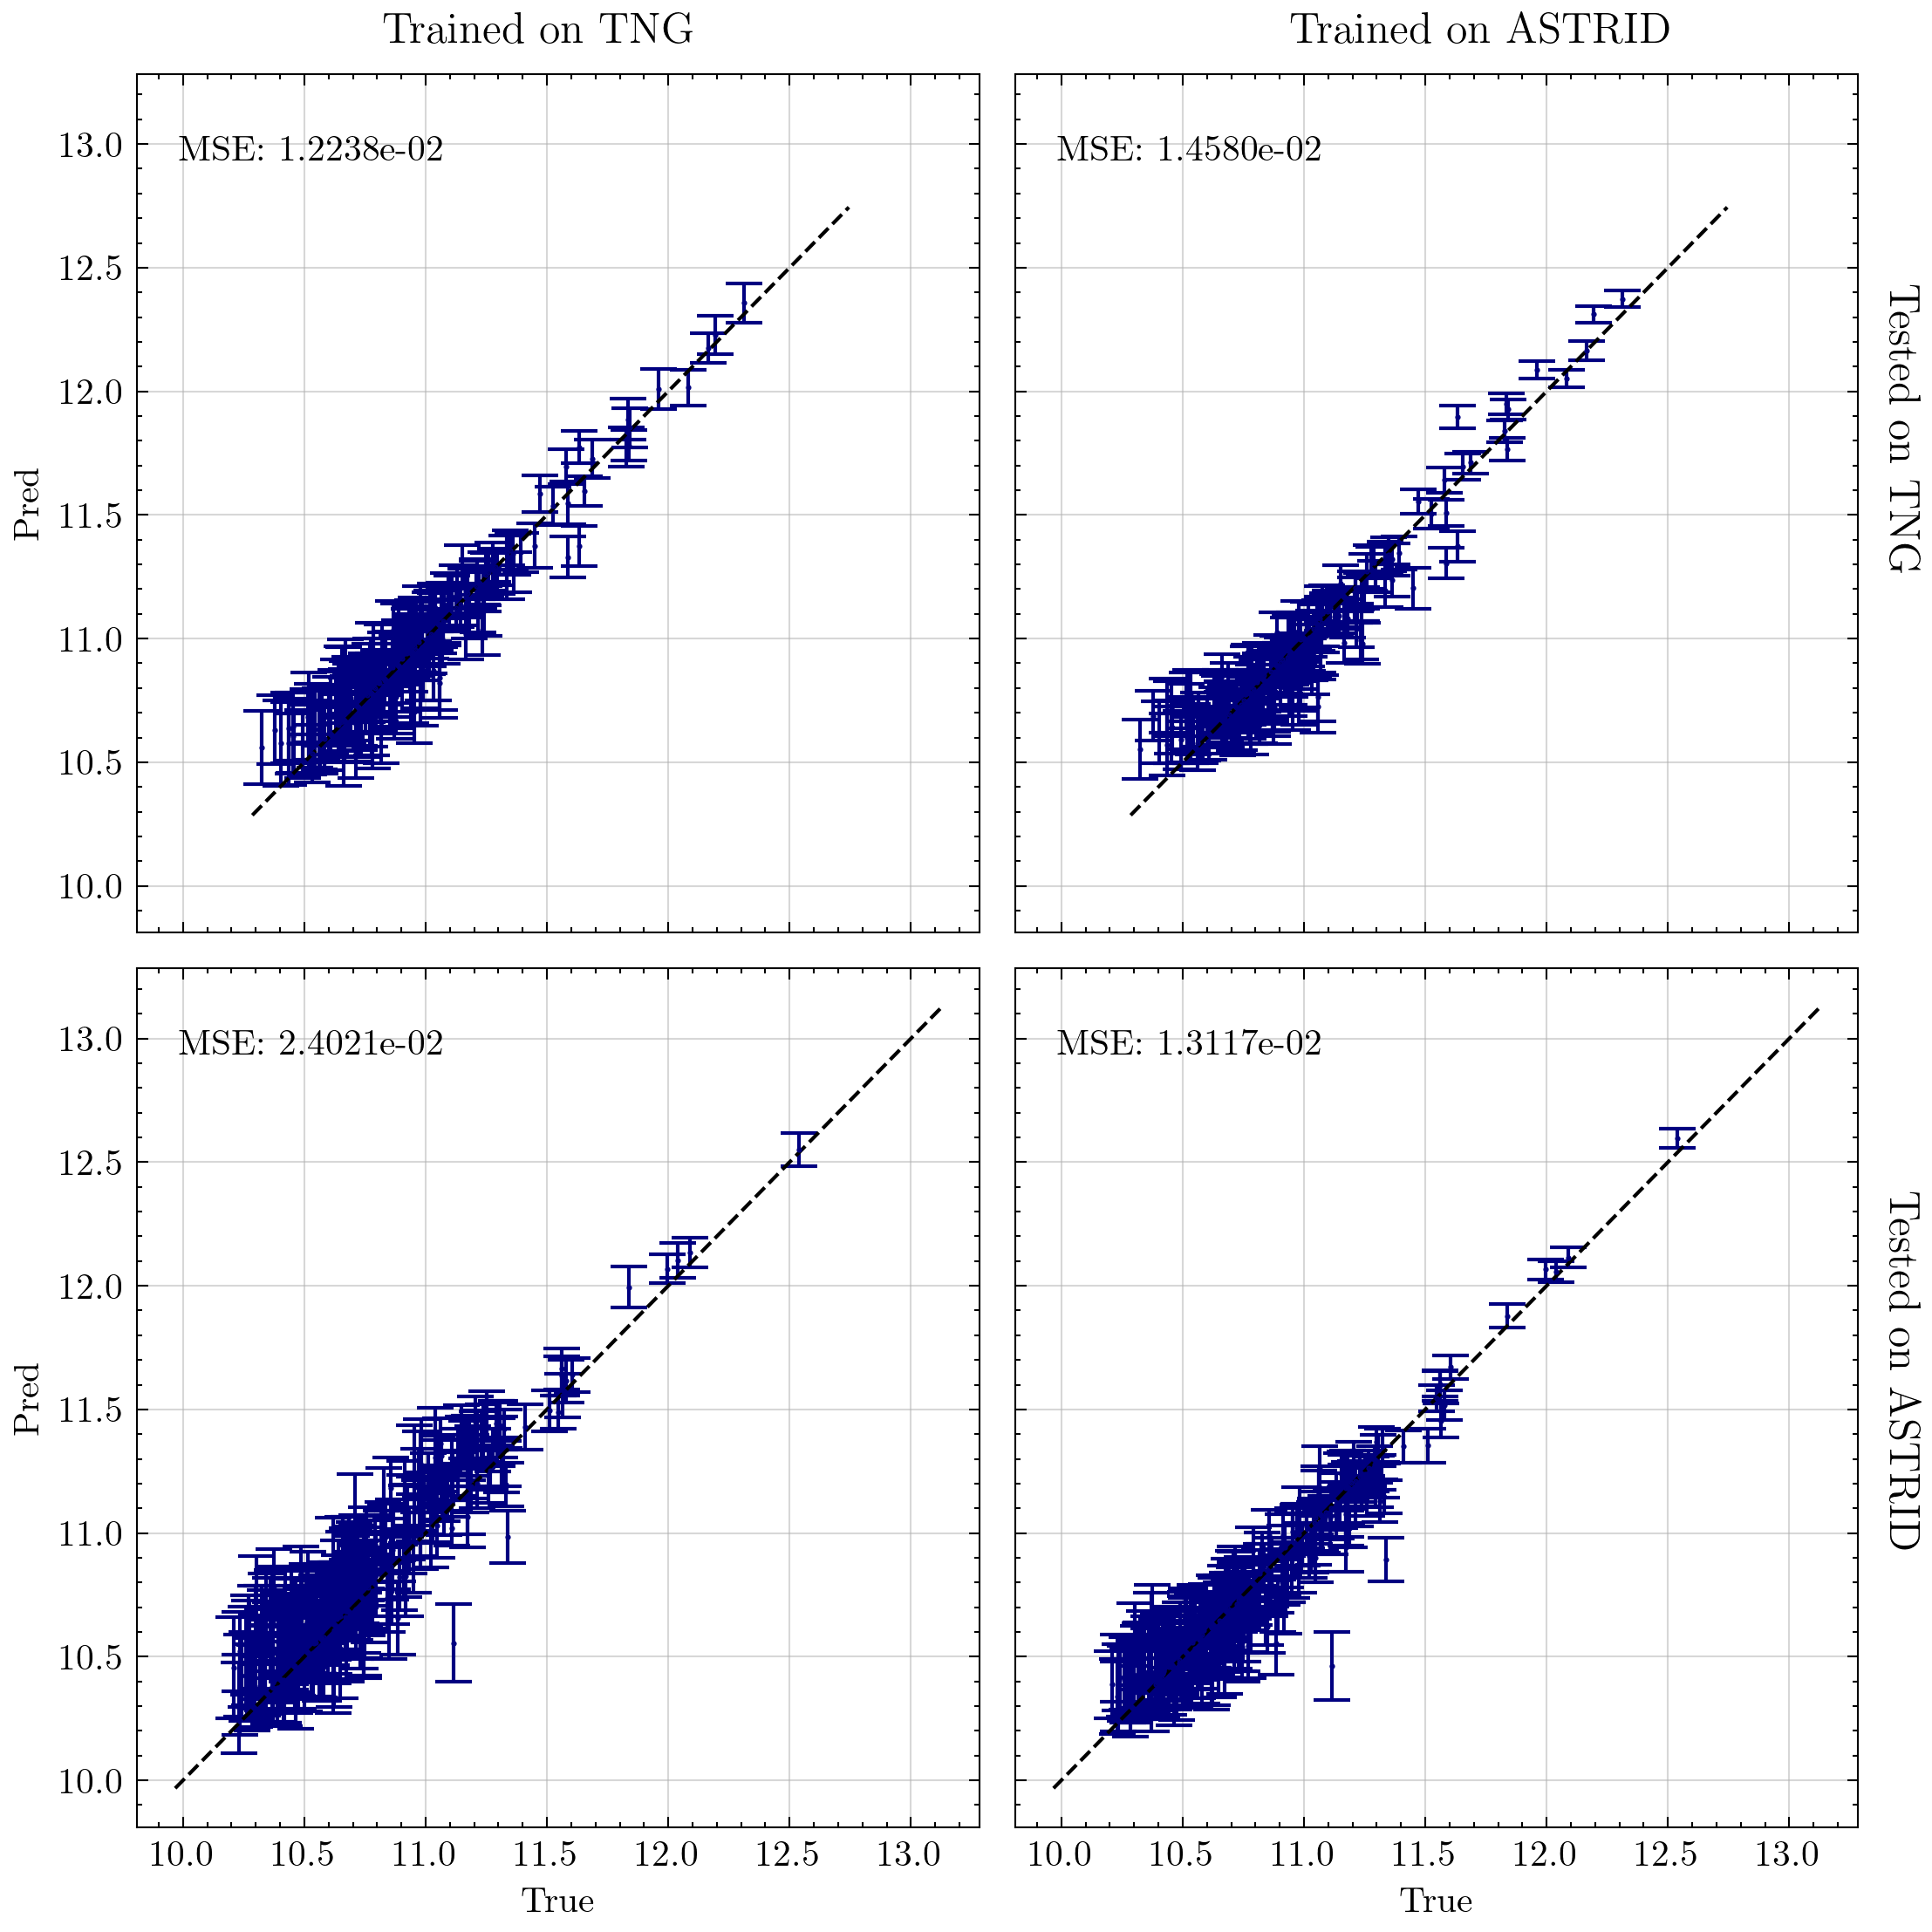

In [9]:
fig = make_matrix_plots(
    truths, 
    predictions, 
    trained_on, 
    tested_on, 
    plot_every_n_points={'TNG': 10, 'ASTRID': 500}
)

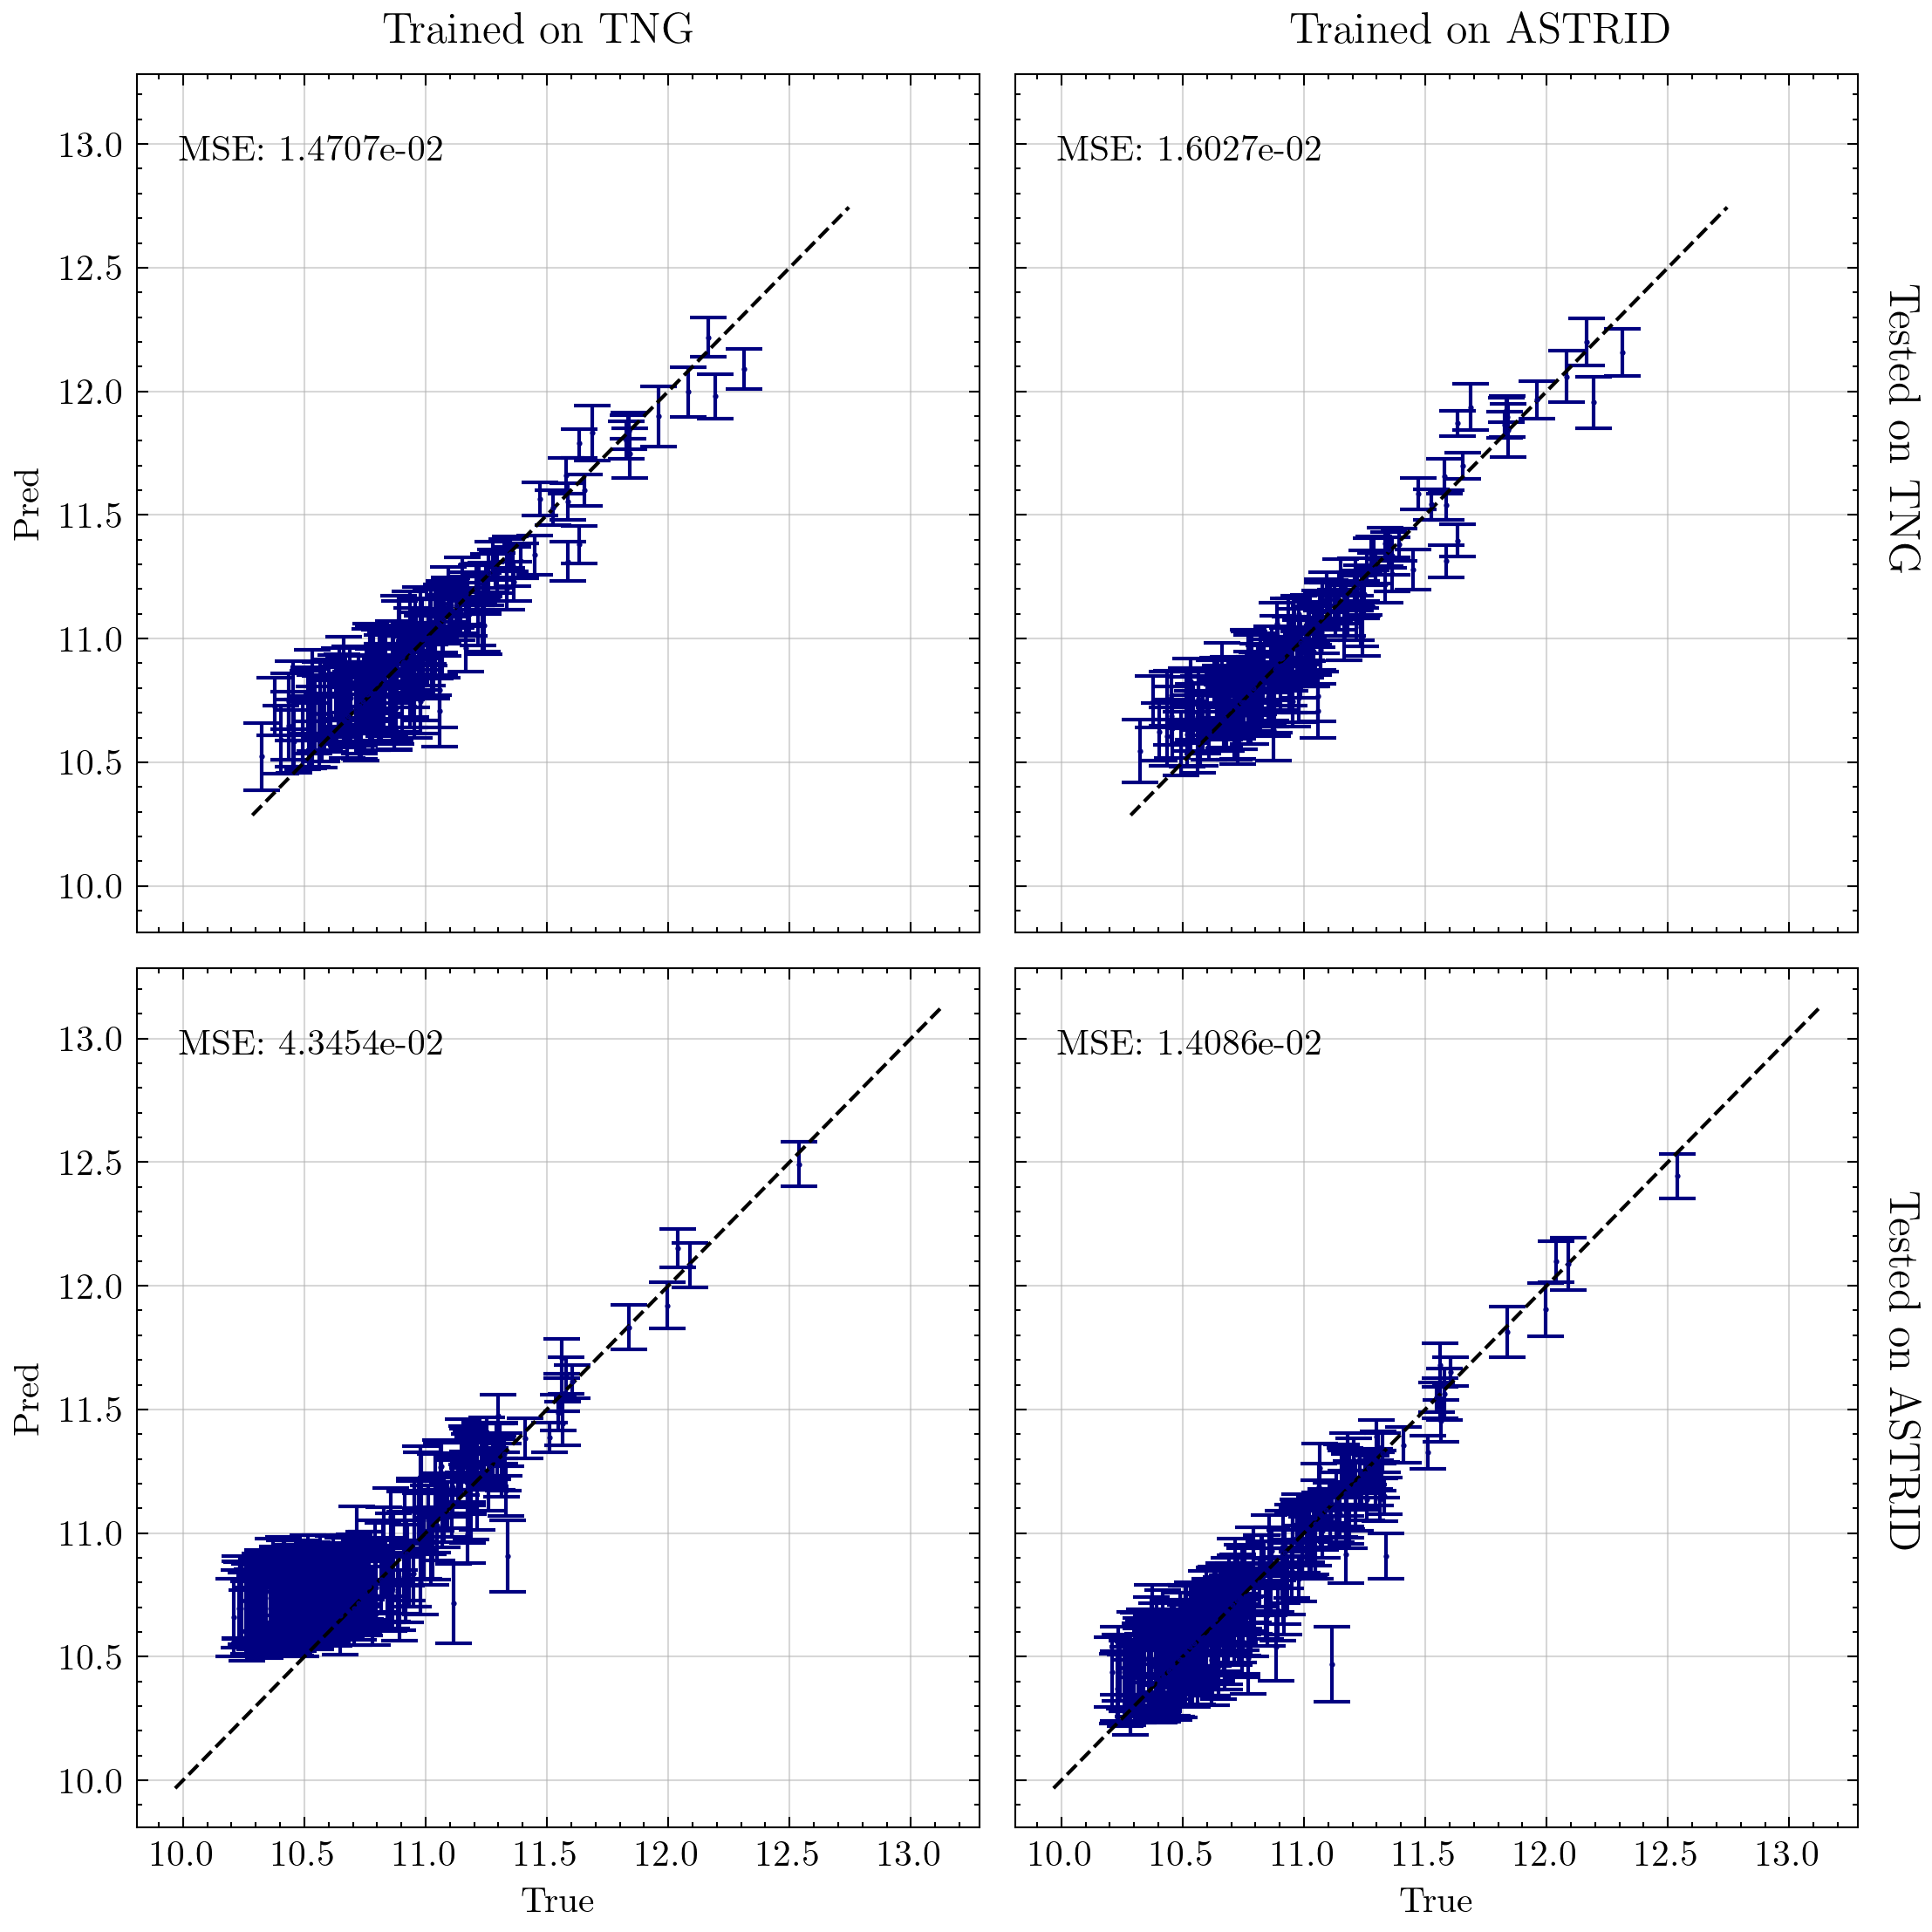

In [28]:
fig = make_matrix_plots(
    truths_observable, 
    predictions_observable, 
    trained_on, 
    tested_on,
    plot_every_n_points={'TNG': 10, 'ASTRID': 500},
)
plt.savefig(f'paper_figures/true_vs_pred_matrix.pdf')

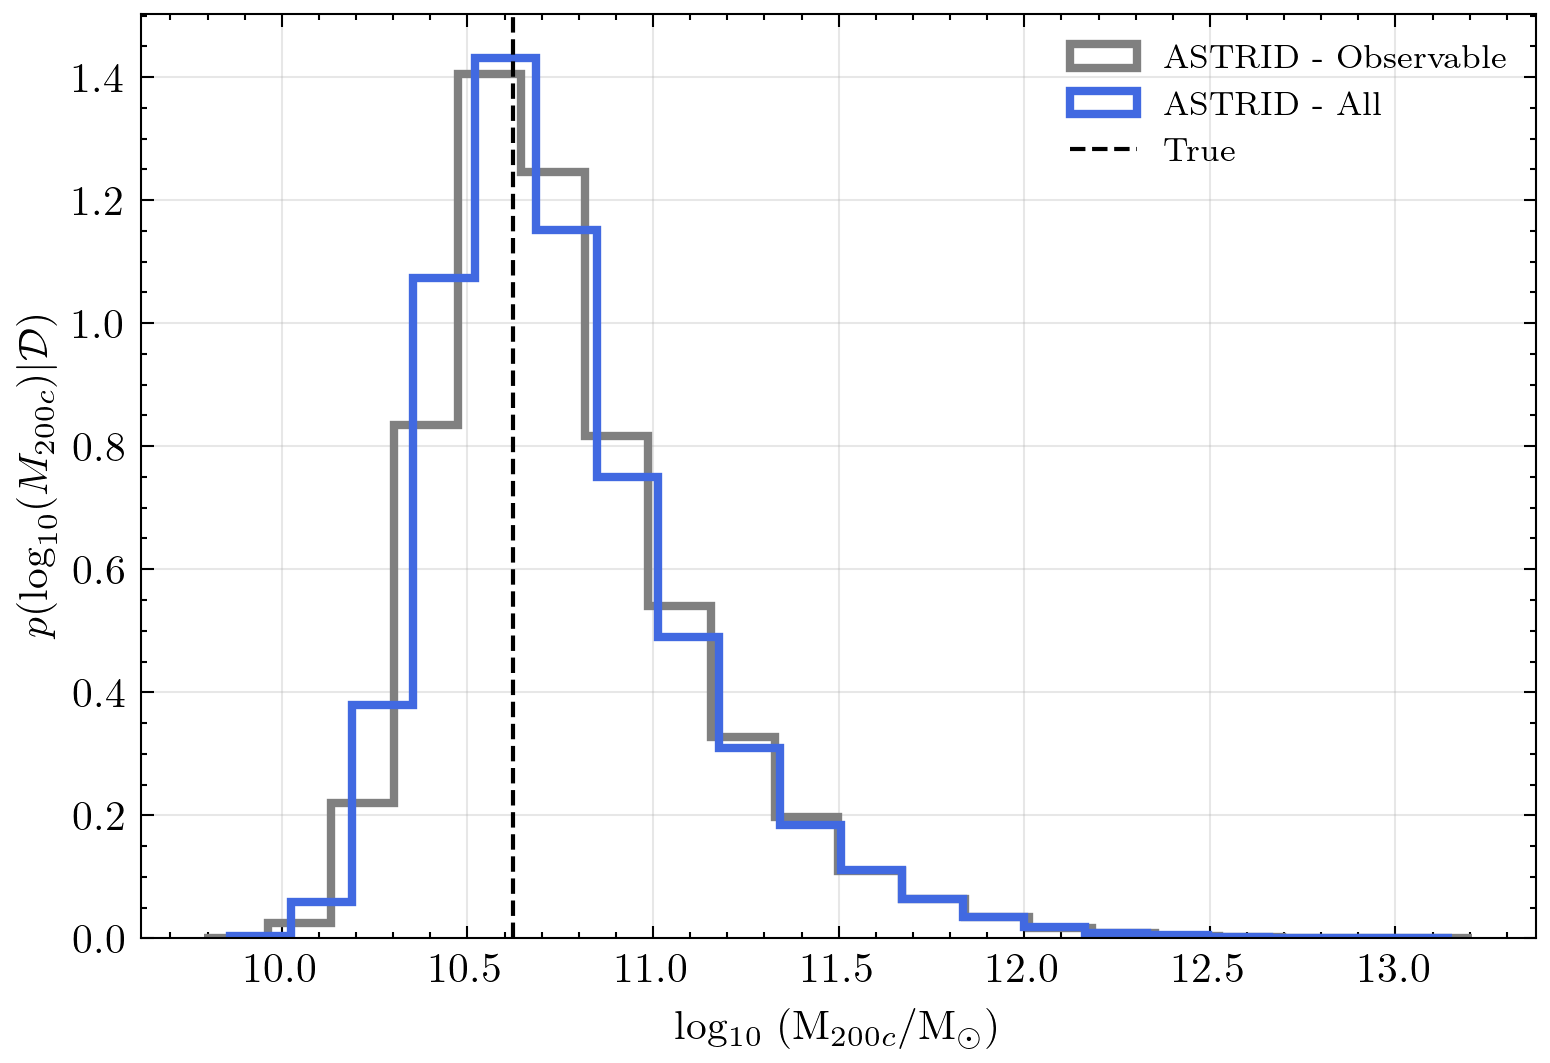

In [27]:
idx = 110
n_bins = 20
train_sim = 'ASTRID'
test_sim = 'ASTRID'
plt.figure(figsize=(6, 4))

plt.hist(predictions_observable[f'{train_sim}_{test_sim}'][idx], bins=n_bins, histtype='step', 
         density=True, label=f'{train_sim} - Observable', color='gray', linewidth=2)
plt.hist(predictions[f'{train_sim}_{test_sim}'][idx], bins=n_bins, histtype='step',
         density=True, label=f'{test_sim} - All', color='royalblue', linewidth=2)

plt.axvline(truths_observable[f'{train_sim}_{test_sim}'][idx], color='black', 
            linestyle='--', label='True')

plt.xlabel('log$_{10}$ (M$_{200c}$/M$_{\odot}$)')
plt.ylabel(r'$p(\log_{10} (M_{200c}) | \mathcal{D})$')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.savefig(f'paper_figures/posterior_{train_sim}_{test_sim}_idx{idx}.pdf')
plt.show()

In [24]:


def compute_hmf_with_uncertainties(
    true_masses, 
    predicted_mass_samples, 
    volume, 
    bins=20, 
    mass_range=(10, 13),
):

    mass_bins = np.linspace(mass_range[0], mass_range[1], bins+1)
    bin_centers = (mass_bins[1:] + mass_bins[:-1]) / 2
    bin_widths = mass_bins[1:] - mass_bins[:-1]
    
    counts, _ = np.histogram(true_masses, bins=mass_bins)
    true_hmf = counts / (volume * bin_widths)  
    #true_hmf_errs = np.sqrt(counts) / (volume * bin_widths)  # Poisson errors, might want to include in the future?
    
    n_samples = predicted_mass_samples.shape[0]
    sample_hmfs = np.zeros((n_samples, bins))
    
    for i in range(n_samples):
        counts, _ = np.histogram(predicted_mass_samples[i], bins=mass_bins)
        sample_hmfs[i] = counts / (volume * bin_widths)
    
    pred_hmf = np.median(sample_hmfs, axis=0)
    pred_hmf_lower = np.percentile(sample_hmfs, 16, axis=0)
    pred_hmf_upper = np.percentile(sample_hmfs, 84, axis=0)
    
    return bin_centers, true_hmf, pred_hmf, pred_hmf_lower, pred_hmf_upper

def plot_hmf_comparison(bin_centers, true_hmf, 
                       pred_hmf, pred_hmf_lower, pred_hmf_upper):
    """Plot comparison between true and predicted HMFs with uncertainties"""
    plt.figure(figsize=(5, 3))
    
    
    plt.plot(bin_centers, pred_hmf, linestyle='-', color='indianred', label='Predicted HMF')
    plt.fill_between(bin_centers, pred_hmf_lower, pred_hmf_upper, 
                    color='indianred', alpha=0.3, label=r'$1\sigma$ confidence')
    
    plt.plot(bin_centers, true_hmf, color='black', label='True HMF', linewidth=2, linestyle='-')
    plt.yscale('log')
    plt.xlabel(r'log$_{10}$ (M$_{200c}$/M$_{\odot}$)')
    plt.ylabel(r'dn/dlog$_{10}$M [Mpc$^{-3}$]')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    return plt.gca()


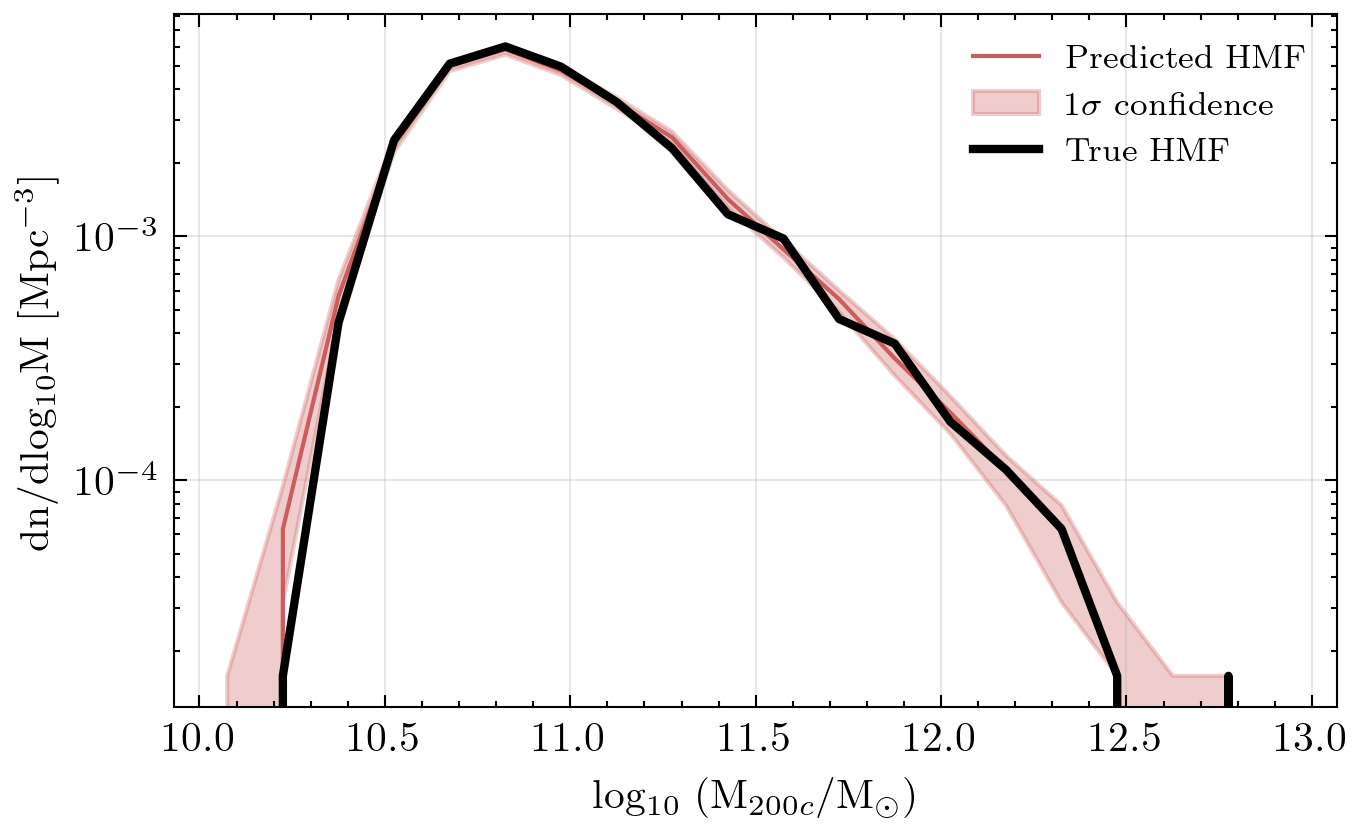

In [29]:

train_sim = 'TNG' 
volume = boxsizes[train_sim]**3  
true_masses = truths[f'{train_sim}_{train_sim}']
predicted_mass_samples = predictions[f'{train_sim}_{train_sim}']
results = compute_hmf_with_uncertainties(true_masses, predicted_mass_samples, volume)
fig = plot_hmf_comparison(*results)
plt.savefig(f'paper_figures/hmf.pdf')